# My Game

## Giesel Library

In [1]:
from text_adventure_games import games, actions, things, blocks


In [2]:
lobby = things.Location("Lobby", "You are standing in the lobby of Giesel Library.")
quiet_study_area = things.Location("8/F Quiet Study Area", "You are on the 8th floor quiet study area.")
chamber_of_secrets = things.Location("Chamber of Secrets", "You are in a hidden chamber beneath the lobby.")
death = things.Location("Heaven", "You have been killed by the Triton snake. GAME OVER.")
death.set_property("game_over", True)
lobby.add_connection("up", quiet_study_area)
lobby.add_connection("down", chamber_of_secrets)


In [3]:
elevator = things.Item("elevator", "a haunted elevator", "THE ELEVATOR GOES UP TO THE QUIET STUDY AREA.")
elevator.set_property("gettable", False)
lobby.add_item(elevator)
trapdoor = things.Item("trapdoor", "a heavy trapdoor", "THE TRAPDOOR HAS A SMALL LOCK")
trapdoor.set_property("gettable", False)
trapdoor.set_property("is_locked", True)
trapdoor.add_command_hint("unlock trapdoor")
lobby.add_item(trapdoor)
key = things.Item("key", "a key", "IT LOOKS LIKE IT FITS IN A LOCK.")
lobby.add_item(key)
sword = things.Item("sword", "a sharp sword", "I'll NEED THIS TO FIGHT OFF ANY DANGER")
sword.set_property("is_weapon", True)
quiet_study_area.add_item(sword)


In [4]:
player = things.Character(name="The player", description="You are a student exploring Giesel Library after hours.", persona="I want to uncover the library's secrets.")
snake = things.Character(name="snake", description="A giant Triton snake with hungry eyes.", persona="I guard the chamber.")
snake.set_property("is_dead", False)
snake.set_property("character_type", "monster")
chamber_of_secrets.add_character(snake)


In [5]:
class Unlock_Trapdoor(actions.Action):
    ACTION_NAME = "unlock trapdoor"
    ACTION_DESCRIPTION = "Unlock the trapdoor with the key"

    def __init__(self, game, command):
        super().__init__(game)
        self.character = self.parser.get_character(command)
        self.key = self.parser.match_item("key", self.parser.get_items_in_scope(self.character))
        self.trapdoor = self.parser.match_item("trapdoor", self.parser.get_items_in_scope(self.character))

    def check_preconditions(self) -> bool:
        if not self.was_matched(self.trapdoor, "There is no trapdoor here."):
            return False
        if not self.trapdoor.get_property("is_locked"):
            self.parser.fail("The trapdoor is already unlocked.")
            return False
        if not self.was_matched(self.key, "You need a key."):
            return False
        if not self.character.is_in_inventory(self.key):
            self.parser.fail("You need the key first.")
            return False
        return True

    def apply_effects(self):
        self.trapdoor.set_property("is_locked", False)
        self.parser.ok("The player unlocked the trapdoor")


class Fight_Snake(actions.Action):
    ACTION_NAME = "fight snake"
    ACTION_DESCRIPTION = "Fight the Triton snake"

    def __init__(self, game, command):
        super().__init__(game)
        self.character = self.game.player
        self.snake = self.character.location.characters.get("snake")
        self.sword = self.parser.match_item("sword", self.character.inventory)

    def check_preconditions(self) -> bool:
        if not self.was_matched(self.snake, "There is no snake here."):
            return False
        if self.snake.get_property("is_dead"):
            self.parser.fail("The snake is already dead.")
            return False
        return True

    def apply_effects(self):
        if self.sword and self.character.is_in_inventory(self.sword):
            self.snake.set_property("is_dead", True)
            self.character.location.remove_character(self.snake)
            self.parser.ok("The player slays the Triton snake with the sword.")
        else:
            self.character.set_property("is_dead", True)
            self.parser.ok("The Triton snake kills the player.")


class Trapdoor_Block(blocks.Block):
    def __init__(self, location: things.Location, trapdoor: things.Item):
        super().__init__("A locked trapdoor blocks your way", "The trapdoor is locked.")
        self.location = location
        self.trapdoor = trapdoor

    def is_blocked(self) -> bool:
        return self.trapdoor.get_property("is_locked")


In [6]:
trapdoor_block = Trapdoor_Block(lobby, trapdoor)
lobby.add_block("down", trapdoor_block)


In [7]:
class GieselLibrary(games.Game):
    def __init__(self, start_at: things.Location, player: things.Character, characters=None, custom_actions=None):
        super().__init__(start_at, player, characters=characters, custom_actions=custom_actions)

    def is_won(self) -> bool:
        snake = self.characters["snake"]
        if snake.get_property("is_dead"):
            self.parser.ok("The Triton snake has been killed. You have conquered the Chamber of Secrets and won the game!")
            return True
        return False


In [8]:
characters = [snake]
custom_actions = [Unlock_Trapdoor, Fight_Snake]
game = GieselLibrary(lobby, player, characters=characters, custom_actions=custom_actions)


In [9]:
tempgame = game


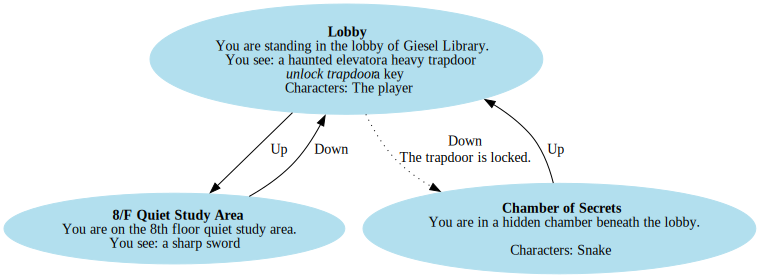

In [10]:
from text_adventure_games.viz import Visualizer
viz = Visualizer(tempgame)
graph = viz.visualize()
graph


In [ ]:
game.game_loop()


You are in a hidden chamber beneath the lobby.
Exits:
Up to Lobby




I'm not sure what you want to do.
I'm not sure what you want to do.
I'm not sure what you want to do.
I'm not sure what you want to do.
